In [ ]:
%pip install --quiet "pytorch_lightning>=2.6,<3,!=2.6.2,!=2.6.3" albumentations "jsonargparse[signatures]"

In [1]:
# Standard Library imports
import sys
from pathlib import Path
from types import SimpleNamespace
import yaml

# Add project root to path so local modules are importable from the notebooks/ folder
sys.path.insert(0, str(Path("..").resolve()))

# External imports
import lightning as pl
import matplotlib.pyplot as plt
import pandas as pd
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from torchvision.utils import make_grid

# Local imports
from datamodule import KenyaDataModule, denormalize
from model import FineTuningWithResNet

# Load configuration from YAML
with open(Path("../config.yaml")) as f:
    _cfg = yaml.safe_load(f)

data_config = SimpleNamespace(
    ROOT_FOLDER=_cfg["data"]["root_folder"],
    NUM_CLASSES=_cfg["model"]["num_classes"],
)

train_config = SimpleNamespace(
    BATCH_SIZE=_cfg["data"]["batch_size"],
    NUM_WORKERS=_cfg["data"]["num_workers"],
    PATIENCE=_cfg["trainer"]["callbacks"][0]["init_args"]["patience"],
    EPOCHS=_cfg["trainer"]["max_epochs"],
    PRECISION=_cfg["trainer"]["precision"],
    MODEL_NAME=_cfg["model"]["resnet_model_name"],
    WEIGHTS=_cfg["model"]["weights"],
    MAX_LR=_cfg["model"]["optimizer"]["init_args"]["lr"],
    FAST_DEV_RUN=_cfg["trainer"]["fast_dev_run"],
    GRADIENT_ACCUMULATION=1,
    LOAD_MODEL=False,
    TRAINED_MODEL_PATH=None,
    LAYERS=None,
    WARMUP_EPOCHS=_cfg["trainer"]["max_epochs"],
)

### Visualization of some augmented images 

Note: The normalization is removed to be able to perceive the other transformations.

C:\Users\Manuel\Desktop\Documentos\1.PROJECTS\COMPUTER VISION\DLPT-food-classification\datamodule.py:68: UserWarning: Argument(s) 'rotate_limit, scale_limit, value' are not valid for transform Affine
  A.Affine(
C:\Users\Manuel\Desktop\Documentos\1.PROJECTS\COMPUTER VISION\DLPT-food-classification\datamodule.py:75: UserWarning: Argument(s) 'alpha_affine, value' are not valid for transform ElasticTransform
  A.ElasticTransform(
C:\Users\Manuel\Desktop\Documentos\1.PROJECTS\COMPUTER VISION\DLPT-food-classification\datamodule.py:84: UserWarning: Argument(s) 'value' are not valid for transform GridDistortion
  A.GridDistortion(


Images batch shape: torch.Size([25, 3, 224, 224])
Labels batch shape: torch.Size([25])


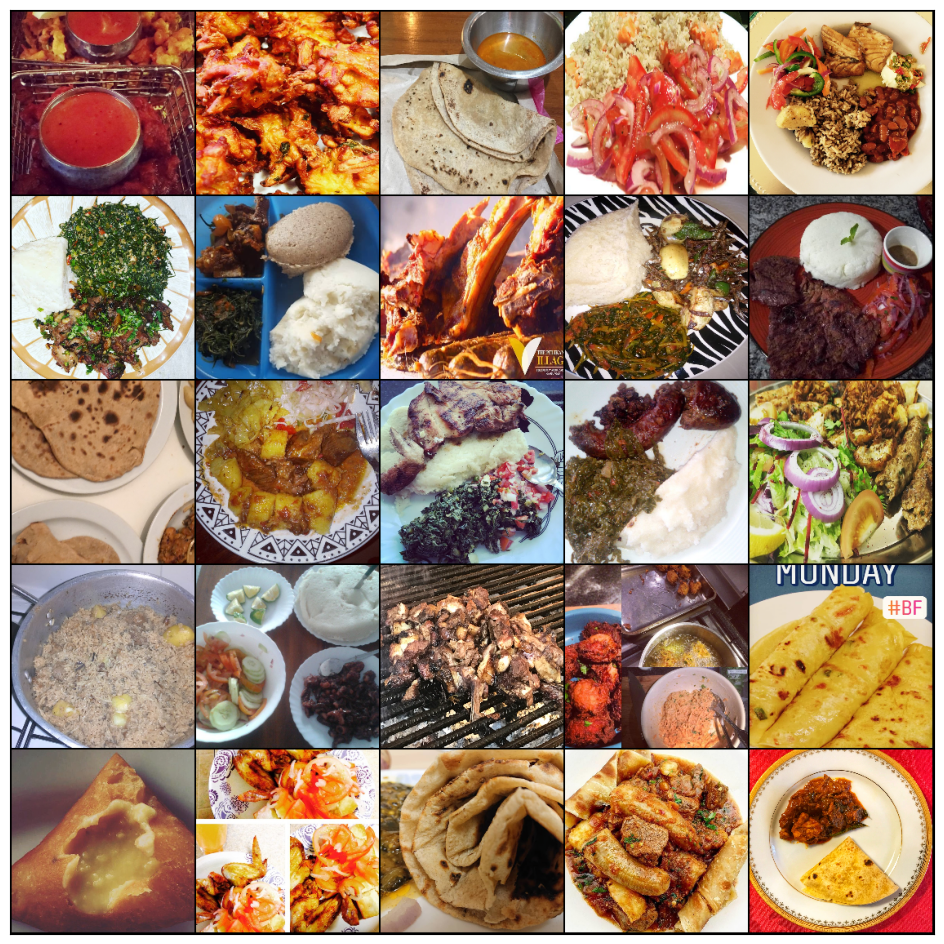

In [3]:
dm = KenyaDataModule(root_folder=data_config.ROOT_FOLDER, batch_size=25)
dm.setup()
dataloader = dm.val_dataloader()

images, labels = next(iter(dataloader))
print(f"Images batch shape: {images.size()}")
print(f"Labels batch shape: {labels.size()}")

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_xticks([])
ax.set_yticks([])

images = denormalize(images)
ax.imshow(make_grid(images, nrow=5).permute(1, 2, 0))
plt.show()

In [ ]:
data_module = KenyaDataModule(
    root_folder=data_config.ROOT_FOLDER,
    batch_size=train_config.BATCH_SIZE,
    num_workers=train_config.NUM_WORKERS,
)

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor="valid/acc",
    mode="max",
    filename="fine-tuning-resnet50-epoch-{epoch:02d}",
    auto_insert_metric_name=False,
    save_weights_only=True,
)

early_stopping_callback = EarlyStopping(
    monitor="valid/loss", min_delta=1e-3, patience=train_config.PATIENCE
)

callbacks = [early_stopping_callback, checkpoint_callback]

In [ ]:
trainer = pl.Trainer(
    accelerator="auto",
    devices="auto",
    strategy="auto",
    max_epochs=train_config.EPOCHS,
    precision=train_config.PRECISION,
    callbacks=callbacks,
    logger=TensorBoardLogger("logs", name=train_config.MODEL_NAME),
    accumulate_grad_batches=train_config.GRADIENT_ACCUMULATION,
    fast_dev_run=train_config.FAST_DEV_RUN
)

In [ ]:
if train_config.LOAD_MODEL:
    if Path(train_config.TRAINED_MODEL_PATH).exists():
        model = FineTuningWithResNet.load_from_checkpoint(
            train_config.TRAINED_MODEL_PATH
        )
        model.freeze_backbone()
        model.unfreeze_backbone_layers(train_config.LAYERS)
        model.unfreeze_head()
        print(f"Model loaded: '{train_config.TRAINED_MODEL_PATH}'")

    else:
        raise Exception("Model doesn't exist")

else:
    model = FineTuningWithResNet(
        resnet_model_name=train_config.MODEL_NAME,
        weights=train_config.WEIGHTS,
        num_classes=data_config.NUM_CLASSES,
        max_lr=train_config.MAX_LR,
    )

    model.freeze_backbone()

    trainer.fit_loop.max_epochs = train_config.WARMUP_EPOCHS

In [ ]:
pl.seed_everything(21, workers=True)
trainer.fit(model, data_module)

In [ ]:
model = FineTuningWithResNet.load_from_checkpoint(checkpoint_callback.best_model_path)
model.eval()
model.freeze()

In [ ]:
trainer.validate(model, data_module)

In [ ]:
fig_, ax_ = model.confusion_matrix.plot()

### Prepare predictions

In [ ]:
results = trainer.predict(model, data_module)

In [ ]:
predictions = []
imageids = []
for res in results:
    ids, preds = res
    imageids.extend(ids)
    predictions.extend(preds.tolist())

predictions = data_module.le.inverse_transform(predictions)
df = pd.DataFrame({"id": imageids, "class": predictions})
df.to_csv("predictions.csv", index=False)
print(df)